# Model development

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier

from src.data.load_data import load_raw_data, split_features_target
from src.utils.config import RANDOM_STATE, TEST_SIZE

## Train/test split

In [3]:
df = load_raw_data()
X, y = split_features_target(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

X_train.shape, X_test.shape

((100, 6), (26, 6))

Stratified so the 55/45 split found in EDA is preserved in both the train and test sets.

## LazyPredict screening

In [4]:
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train, X_test, y_train, y_test)
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
AdaBoostClassifier,0.730769,0.714286,0.767857,0.715740,0.764025,0.730769,0.102929
SGDClassifier,0.692308,0.690476,0.767857,0.692308,0.692308,0.692308,0.015539
NearestCentroid,0.692308,0.684524,0.779762,0.688578,0.693269,0.692308,0.016978
BernoulliNB,0.692308,0.678571,0.788690,0.680769,0.705128,0.692308,0.941623
DecisionTreeClassifier,0.653846,0.660714,0.660714,0.652308,0.668531,0.653846,0.015066
RandomForestClassifier,0.653846,0.660714,0.678571,0.652308,0.668531,0.653846,0.109852
CalibratedClassifierCV,0.653846,0.630952,0.696429,0.617195,0.702564,0.653846,0.048655
ExtraTreesClassifier,0.615385,0.613095,0.616071,0.615385,0.615385,0.615385,0.092308
BaggingClassifier,0.615385,0.613095,0.622024,0.615385,0.615385,0.615385,0.039512


AdaBoost and RandomForest moved forward into tuning. These were the two strongest results in this table.

## Hyperparameter tuning

Using train_test_split for a single validation split.

In [5]:
from src.models.train import MODELS, tune_model

In [6]:
import pandas as pd

rows = []
for name in MODELS:
    search = tune_model(name, X_train, y_train)
    rows.append({
        "model": name,
        "val_score": search.best_score_,
        "best_params": search.best_params_,
    })

results_df = pd.DataFrame(rows)
results_df

,model,val_score,best_params
0,AdaBoost,0.65,"{'learning_rate': 1.0, 'n_estimators': 50}"
1,RandomForest,0.80,"{'max_depth': None, 'n_estimators': 200}"


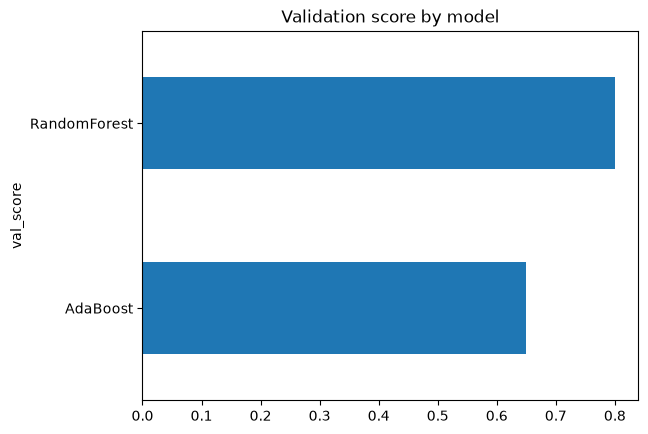

In [7]:
results_df.plot(x="model", y="val_score", kind="barh", legend=False)
plt.title("Validation score by model")
plt.ylabel("val_score")
plt.show()

RandomForest scores higher, but this is from a small validation split so it could be overfitted.

## Final evaluation

In [8]:
from src.models.evaluate import evaluate_on_test_set, print_report, plot_confusion_matrix, plot_feature_importance
from src.utils.config import FEATURE_COLS

final_models = {}
for name in MODELS:
    search = tune_model(name, X_train, y_train)
    final_models[name] = search.best_estimator_

AdaBoost
              precision    recall  f1-score   support

     unhappy       0.86      0.50      0.63        12
       happy       0.68      0.93      0.79        14

    accuracy                           0.73        26
   macro avg       0.77      0.71      0.71        26
weighted avg       0.76      0.73      0.72        26

beat 73% target: True


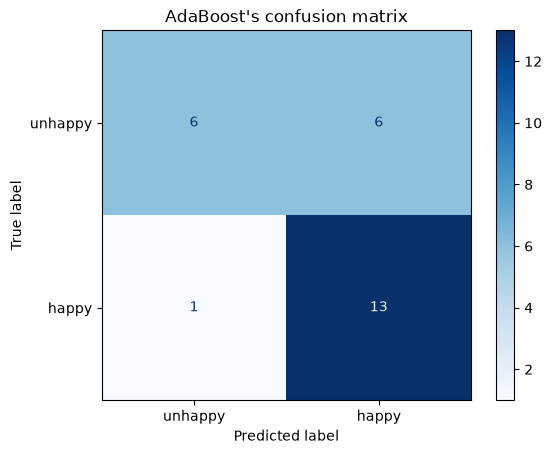

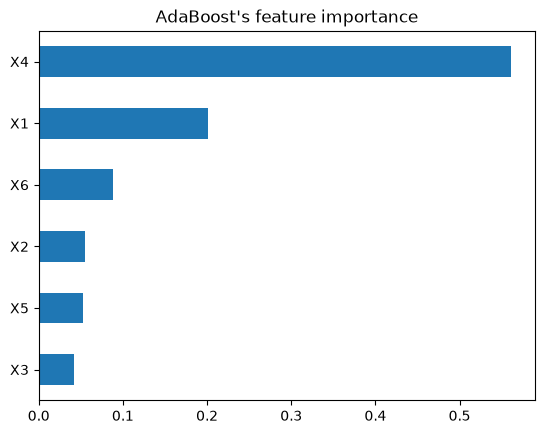

RandomForest
              precision    recall  f1-score   support

     unhappy       0.62      0.67      0.64        12
       happy       0.69      0.64      0.67        14

    accuracy                           0.65        26
   macro avg       0.65      0.65      0.65        26
weighted avg       0.66      0.65      0.65        26

beat 73% target: False


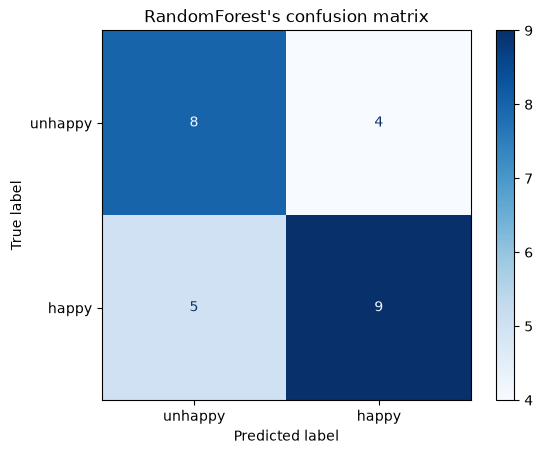

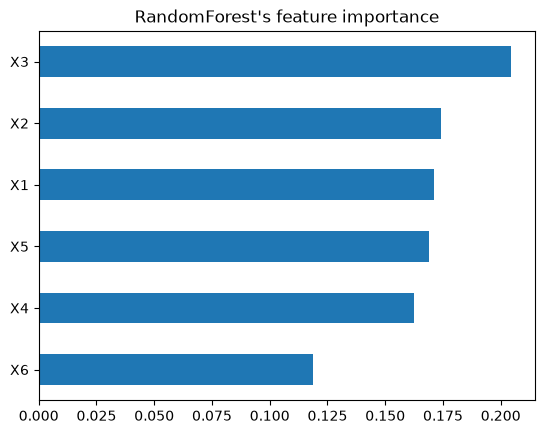

In [9]:
for name, model in final_models.items():
    print_report(model, X_test, y_test, model_name=name)
    plot_confusion_matrix(model, X_test, y_test, model_name=name)
    plot_feature_importance(model, FEATURE_COLS, model_name=name)

## Summary

- AdaBoost hits the 73% accuracy target, RandomForest does not (63%).
- However, AdaBoost only catches half of the unhappy customers (50% recall), while RandomForest catches two-thirds (67%).
- The project's goal is to predict whether customers are happy or unhappy, so the recall gap is worth weighing against the accuracy target.